In [1]:
import bw2data, bw2io, bw2calc
import numpy as np
import os
import re
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

In [2]:
import sys
sys.path.append('../../../utils/') 
from post_anal_plot import * 

### static LCI +  three GWP
- GWP100
- pGWP-fixed vs. dp-CO2 

In [8]:
wind  = pd.read_excel("../../dp-LCI_output/staticLCI_(p)GWP20/wind_CN_US_staticLCI_threeGWP20.xlsx")
hydro = pd.read_excel("../../dp-LCI_output/staticLCI_(p)GWP20/hydro_reservoir_CN-asRoW_US-asQC_staticLCI_threeGWP20.xlsx")
pv    = pd.read_excel("../../dp-LCI_output/staticLCI_(p)GWP20/PV_CN_US_staticLCI_threeGWP20.xlsx")

In [9]:
def tidy(df, tech_label):
    parts = df["Activity"].str.split(", ", expand=True)
    out = df.copy()
    out["Technology"] = tech_label
    out["Country"]    = parts[3].str[:2]
    out["SSP"]        = parts[4]
    out["Year"]       = parts[5].astype(int)
    return out[["Technology", "Country", "SSP", "Year",
                "gwp20", "pGWP20_fixedCO2", "pGWP20_dpCO2"]]

all_df = pd.concat(
    [tidy(wind,  "Wind"),
     tidy(hydro, "Hydro"),
     tidy(pv,    "PV")],
    ignore_index=True,
)

# Keep only 2030 & 2050
df = all_df[all_df["Year"].isin([2030, 2050])].copy()

# long format over metrics
metric_cols = ["gwp20", "pGWP20_fixedCO2", "pGWP20_dpCO2"]
df_long = df.melt(
    id_vars=["Technology", "Country", "SSP", "Year"],
    value_vars=metric_cols,
    var_name="Metric",
    value_name="Score",
)

df_long


,Technology,Country,SSP,Year,Metric,Score
0,Wind,CN,SSP1-VLLO,2030,gwp20,0.040977
1,Wind,CN,SSP1-VLLO,2050,gwp20,0.020379
2,Wind,CN,SSP2-M,2030,gwp20,0.041837
3,Wind,CN,SSP2-M,2050,gwp20,0.034676
4,Wind,CN,SSP5-H,2030,gwp20,0.042915
...,...,...,...,...,...,...
103,PV,US,SSP1-VLLO,2050,pGWP20_dpCO2,0.007571
104,PV,US,SSP2-M,2030,pGWP20_dpCO2,0.022934
105,PV,US,SSP2-M,2050,pGWP20_dpCO2,0.014793
106,PV,US,SSP5-H,2030,pGWP20_dpCO2,0.023857


In [10]:
df_long.sort_values([ "SSP","Year", "Country", "Technology"	]).to_excel("plot_rankshift_staticLCI_threeGWP20.xlsx")

### WIP we don't have dpLCI yet w/h GWP20  

## now ranking 

In [12]:
# NOW recompute Rank with the two new metrics included
#df_full = df_long

df_full["Rank"] = df_full.groupby(
    ["Country","SSP","Year","Metric"]
)["Score"].rank(method="dense", ascending=True)

df_full

,Technology,Country,SSP,Year,Metric,Score,Rank
0,Hydro,CN,SSP1-VLLO,2030,gwp20,0.061746,3.0
1,Hydro,CN,SSP1-VLLO,2030,pGWP20_fixedCO2,0.070191,3.0
2,Hydro,CN,SSP1-VLLO,2030,pGWP20_dpCO2,0.061253,3.0
3,PV,CN,SSP1-VLLO,2030,gwp20,0.035883,1.0
4,PV,CN,SSP1-VLLO,2030,pGWP20_fixedCO2,0.040738,1.0
...,...,...,...,...,...,...,...
103,PV,US,SSP5-H,2050,pGWP20_fixedCO2,0.016126,1.0
104,PV,US,SSP5-H,2050,pGWP20_dpCO2,0.017781,1.0
105,Wind,US,SSP5-H,2050,gwp20,0.021346,2.0
106,Wind,US,SSP5-H,2050,pGWP20_fixedCO2,0.020071,2.0


In [13]:
metric_rename = {
    "gwp20": "staticLCI + IPCC-GWP",
    "pGWP20_fixedCO2": "staticLCI + pGWP-fixedCO2",
    "pGWP20_dpCO2": "staticLCI + pGWP-dpCO2",
    #"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2": "dyn-FG-LCI + pGWP-fixedCO2",
    #"full dp-LCI, pGWP100-fixedCO2": "full dpLCI + pGWP-fixedCO2"
}

In [14]:
df_full["Metric"] = df_full["Metric"].replace(metric_rename)

In [15]:
df_full_sorted = df_full.sort_values([ "SSP","Year", "Country", "Technology"	]) 
df_full_sorted

,Technology,Country,SSP,Year,Metric,Score,Rank
0,Hydro,CN,SSP1-VLLO,2030,staticLCI + IPCC-GWP,0.061746,3.0
1,Hydro,CN,SSP1-VLLO,2030,staticLCI + pGWP-fixedCO2,0.070191,3.0
2,Hydro,CN,SSP1-VLLO,2030,staticLCI + pGWP-dpCO2,0.061253,3.0
3,PV,CN,SSP1-VLLO,2030,staticLCI + IPCC-GWP,0.035883,1.0
4,PV,CN,SSP1-VLLO,2030,staticLCI + pGWP-fixedCO2,0.040738,1.0
...,...,...,...,...,...,...,...
103,PV,US,SSP5-H,2050,staticLCI + pGWP-fixedCO2,0.016126,1.0
104,PV,US,SSP5-H,2050,staticLCI + pGWP-dpCO2,0.017781,1.0
105,Wind,US,SSP5-H,2050,staticLCI + IPCC-GWP,0.021346,2.0
106,Wind,US,SSP5-H,2050,staticLCI + pGWP-fixedCO2,0.020071,2.0


In [10]:
#df_full_sorted.to_excel("plot_rankshift_hydro_v2_reservoir.xlsx")

## plot 

#### function

#### plot 

### because it's uniform distribution on the FG dyn LCI, 
##### so without full dpLCI (mapping to the right background), it the same score on dyn-FG-LCI vs. static LCI 
##### also, not showing the staticLCI + pGWP-dpCO2' caz in the excel (B.0) it's not changing that much to IPCC-GWP anyways

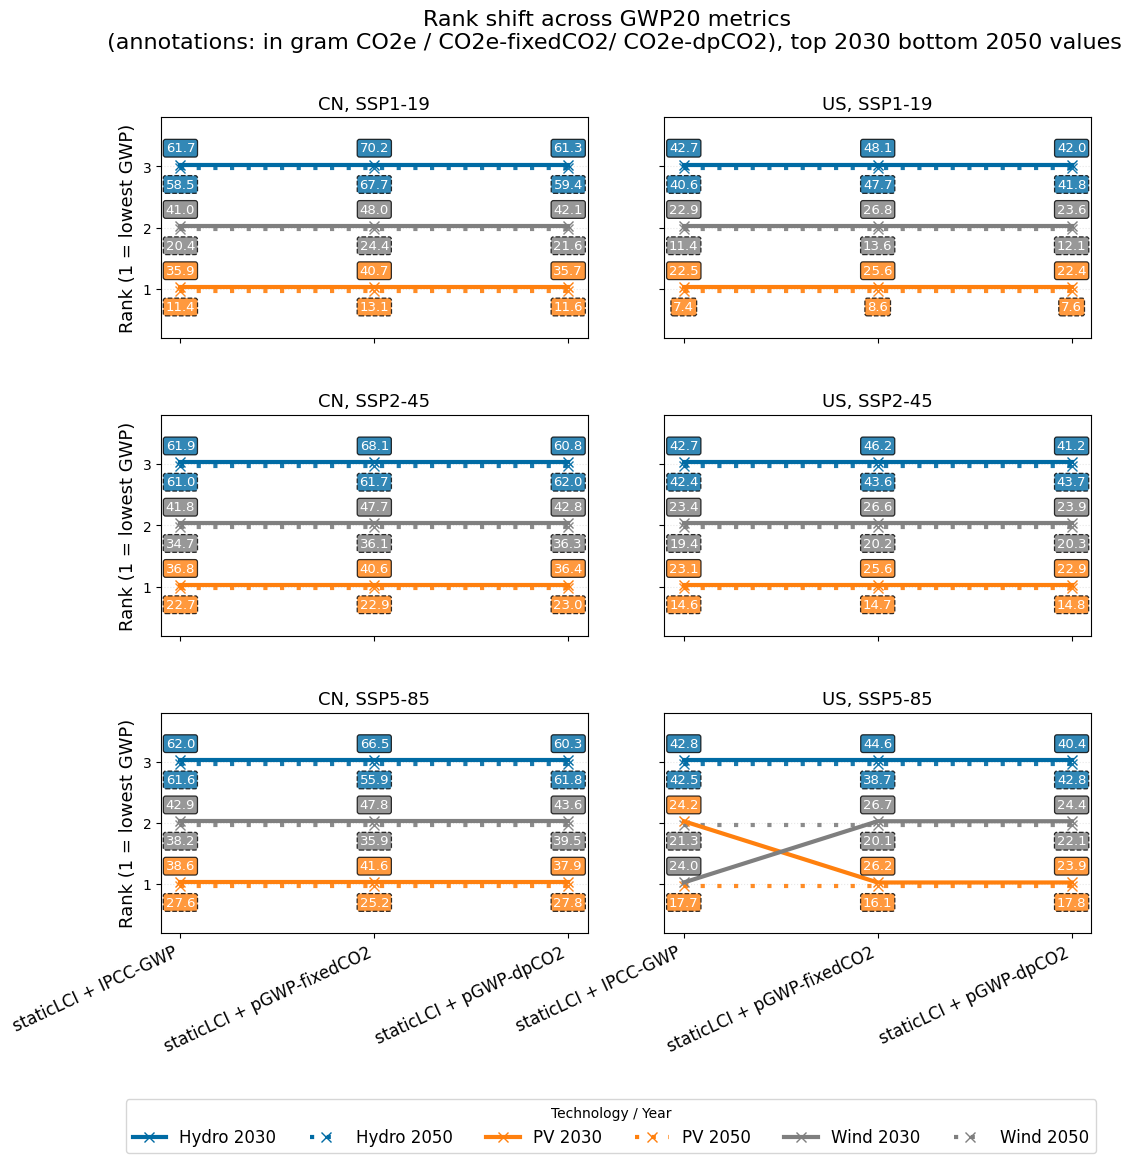

In [16]:
metric_order = [  #'dyn-FG-LCI + pGWP-fixedCO2', 
                  'staticLCI + IPCC-GWP', 
                  'staticLCI + pGWP-fixedCO2', 
                  'staticLCI + pGWP-dpCO2', 
                 #'full dpLCI + pGWP-fixedCO2',
                ]

metric_labels = {
    'staticLCI + IPCC-GWP': 'staticLCI + IPCC-GWP', 
    'staticLCI + pGWP-fixedCO2':'staticLCI + pGWP-fixedCO2', 
    'staticLCI + pGWP-dpCO2': 'staticLCI + pGWP-dpCO2',   
    #'dyn-FG-LCI + pGWP-fixedCO2':'dyn-FG-LCI + pGWP-fixedCO2' ,
    #'full dpLCI + pGWP-fixedCO2': 'full dpLCI + pGWP-fixedCO2',
}

tech_colors = {"PV":"#FF800E","Wind": "#7F7F7F" ,"Hydro": "#006BA4"}

fig, axes = rank_shift_plot_cleanSeparated(
    df_full_sorted, #df_full,
    metric_order=metric_order,
    metric_labels=metric_labels,
    tech_colors=tech_colors,
    fig_title=  "Rank shift across GWP20 metrics \n (annotations: in gram CO2e / CO2e-fixedCO2/ CO2e-dpCO2), top 2030 bottom 2050 values",
)

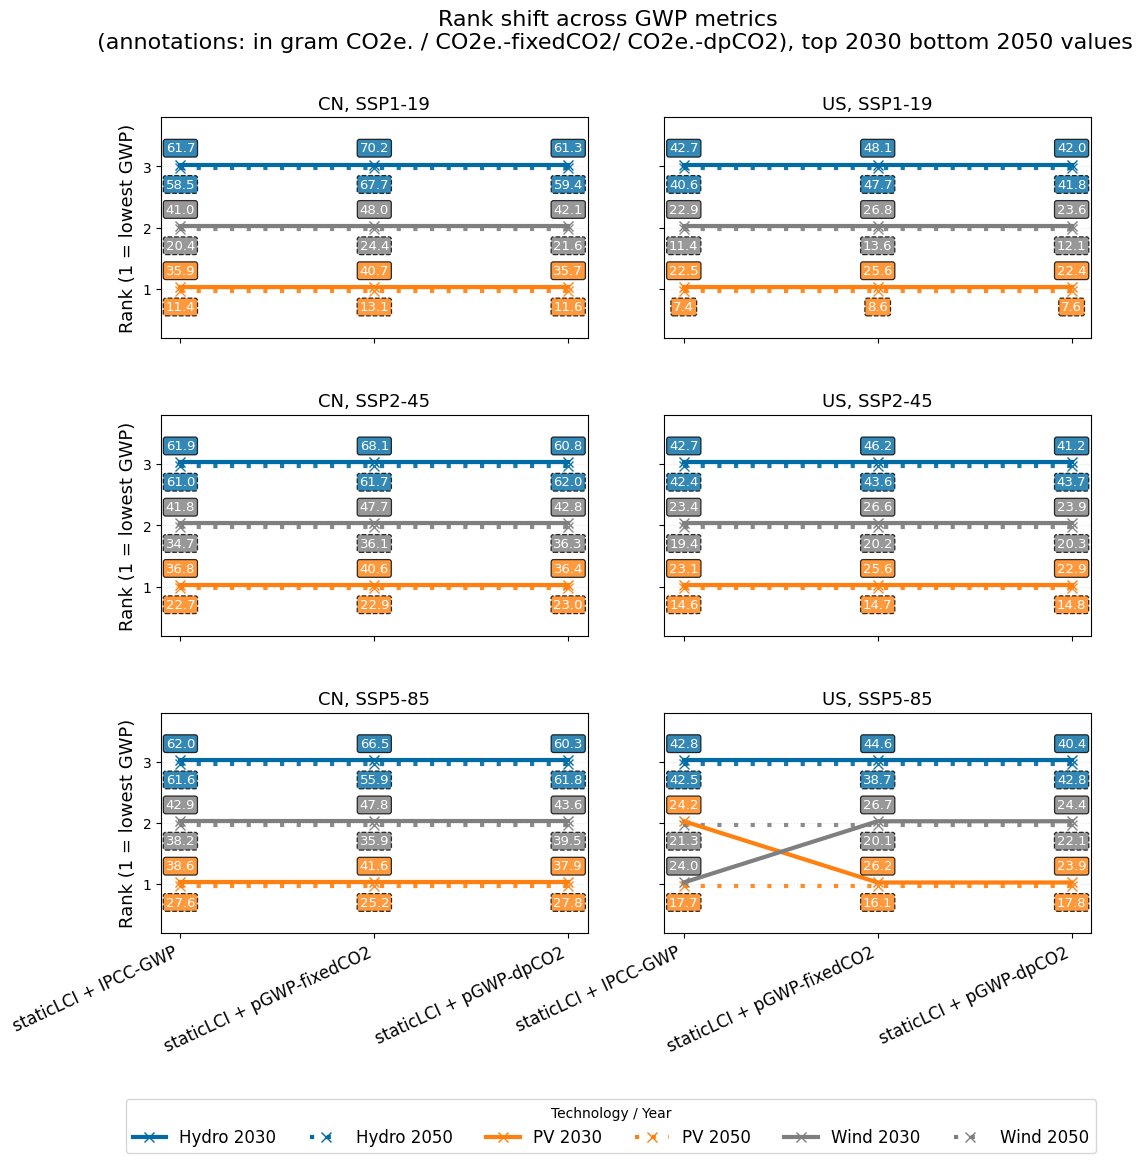

In [12]:
metric_order = [  #'dyn-FG-LCI + pGWP-fixedCO2', 
        
                  'staticLCI + IPCC-GWP', 
                  'staticLCI + pGWP-fixedCO2', 
                  'staticLCI + pGWP-dpCO2', 
                 #'full dpLCI + pGWP-fixedCO2',
                ]

metric_labels = {
    'staticLCI + IPCC-GWP': 'staticLCI + IPCC-GWP', 
    'staticLCI + pGWP-fixedCO2':'staticLCI + pGWP-fixedCO2', 
    'staticLCI + pGWP-dpCO2': 'staticLCI + pGWP-dpCO2',   
    #'dyn-FG-LCI + pGWP-fixedCO2':'dyn-FG-LCI + pGWP-fixedCO2' ,
    #'full dpLCI + pGWP-fixedCO2': 'full dpLCI + pGWP-fixedCO2',
}

tech_colors = {"PV":"#FF800E","Wind": "#7F7F7F" ,"Hydro": "#006BA4"}

fig, axes = rank_shift_plot_cleanSeparated(
    df_full_sorted, #df_full,
    metric_order=metric_order,
    metric_labels=metric_labels,
    tech_colors=tech_colors,
    fig_title=  "Rank shift across GWP20 metrics \n (annotations: in gram CO2e / CO2e-fixedCO2/ CO2e-dpCO2), top 2030 bottom 2050 values",
)